# Moving-source retarded-time and frame-wise DOA validation

This report uses independent frame estimates, **not tracking**. Each moving trial is paired with a stationary trial using the same source and noise. Frame truth is evaluated at the array-centroid emission time.

In [1]:
from pathlib import Path
import csv, sys
import numpy as np
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks': PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from simulation.moving_source import solve_emission_time, constant_velocity_emission_time
from simulation.trajectory import ConstantVelocityTrajectory
CSV_PATH = PROJECT_ROOT / 'results' / 'moving_source_summary.csv'

## Physical model

For every reception time and microphone, $t_e$ is the unique root
$$t=t_e+\|q(t_e)-r_m\|/c,$$
because $d g/dt_e=1+v_r/c>0$ for $|v|<c$. The signal is $x_m(t)=A_m(t_e)s(t_e)$, so Doppler is naturally $dt_e/dt=1/(1+v_r/c)$. No separate Doppler shift is applied.

In [2]:
with CSV_PATH.open(encoding='utf-8', newline='') as stream:
    rows = list(csv.DictReader(stream))
assert len(rows) == 6480
assert len({r['configuration'] for r in rows}) == 2160
assert sum(int(r['trial_count']) for r in rows) // 3 == 43200
assert all(r['independent_framewise_doa_not_tracking'] == 'True' for r in rows)
numeric = ['moving_conditional_rmse_deg','moving_conditional_p95_deg','moving_conditional_p99_deg','moving_coverage','motion_induced_excess_rmse_deg','doa_change_within_frame_deg','max_tdoa_change_within_frame_us','doppler_factor']
assert all(np.isfinite(float(r[field])) for r in rows for field in numeric)
zero = [r for r in rows if float(r['speed_mps']) == 0]
assert max(abs(float(r['motion_induced_excess_rmse_deg'])) for r in zero) < 1e-13
print('rows/configurations/paired trials:', len(rows), len({r['configuration'] for r in rows}), 43200)
print('Doppler-factor range:', min(float(r['doppler_factor']) for r in rows), max(float(r['doppler_factor']) for r in rows))

rows/configurations/paired trials: 6480 2160 43200
Doppler-factor range: 0.9195710455764075 1.0958466453674123


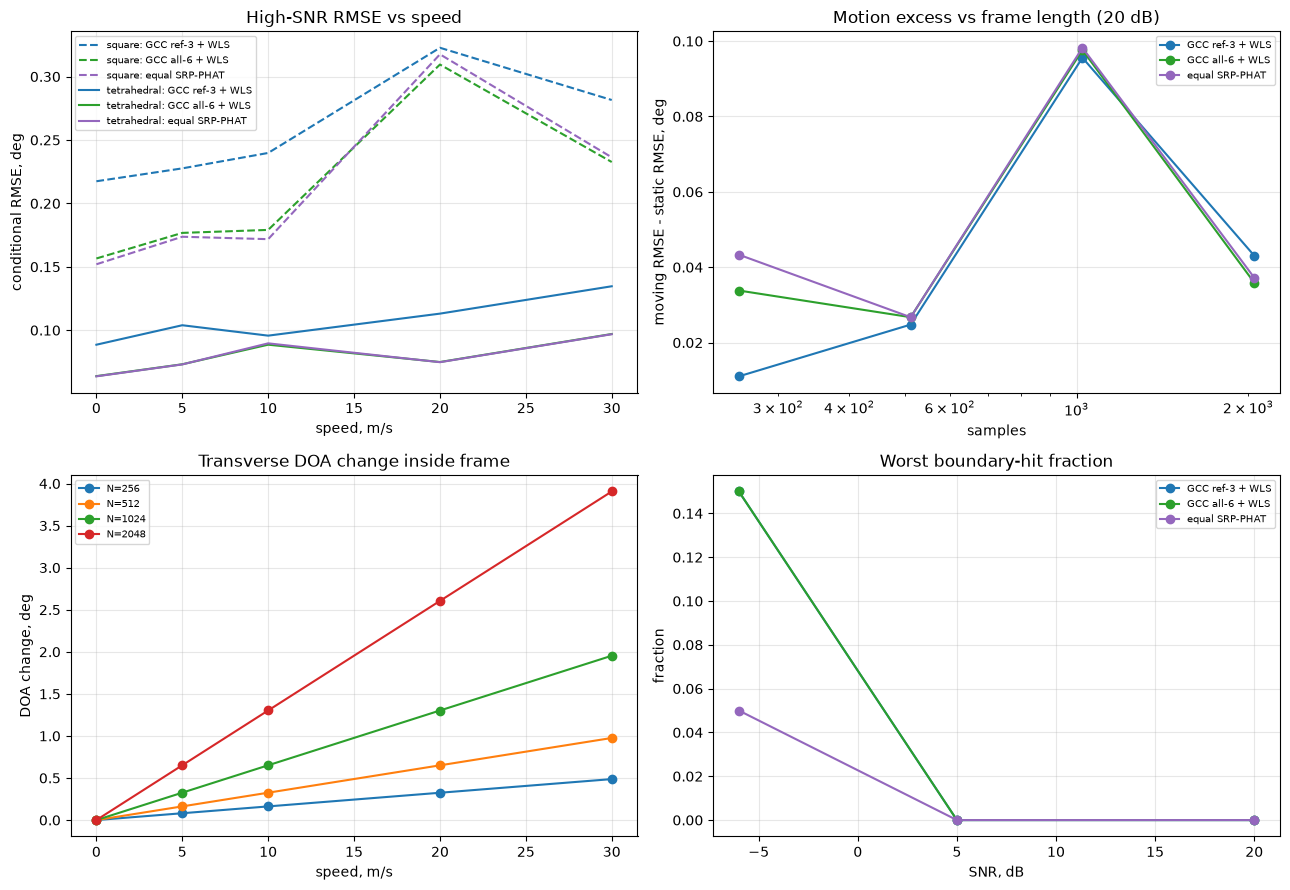

In [3]:
methods = ['reference_3_gcc_wls','all_6_equal_gcc_wls','equal_weight_srp_phat']
labels = {'reference_3_gcc_wls':'GCC ref-3 + WLS','all_6_equal_gcc_wls':'GCC all-6 + WLS','equal_weight_srp_phat':'equal SRP-PHAT'}
colors = {'reference_3_gcc_wls':'tab:blue','all_6_equal_gcc_wls':'tab:green','equal_weight_srp_phat':'tab:purple'}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for geometry, style in [('square','--'),('tetrahedral','-')]:
    for method in methods:
        values=[]
        for speed in (0,5,10,20,30):
            group=[float(r['moving_conditional_rmse_deg']) for r in rows if r['geometry']==geometry and r['estimator_variant']==method and float(r['speed_mps'])==speed and float(r['snr_db'])==20]
            values.append(np.mean(group))
        axes[0,0].plot((0,5,10,20,30), values, style, color=colors[method], label=f'{geometry}: {labels[method]}')
for method in methods:
    values=[]
    for length in (256,512,1024,2048):
        group=[float(r['motion_induced_excess_rmse_deg']) for r in rows if r['estimator_variant']==method and int(r['frame_length'])==length and float(r['snr_db'])==20 and float(r['speed_mps'])>0]
        values.append(np.mean(group))
    axes[0,1].plot((256,512,1024,2048), values, 'o-', color=colors[method], label=labels[method])
unique = {r['configuration']:r for r in rows if r['estimator_variant']=='equal_weight_srp_phat'}
for length in (256,512,1024,2048):
    values=[]
    for speed in (0,5,10,20,30):
        group=[float(r['doa_change_within_frame_deg']) for r in unique.values() if int(r['frame_length'])==length and float(r['speed_mps'])==speed and r['motion']=='transverse']
        values.append(np.mean(group))
    axes[1,0].plot((0,5,10,20,30), values, 'o-', label=f'N={length}')
for method in methods:
    boundary=[]
    for snr in (-6,5,20):
        group=[float(r['moving_boundary_hit_fraction']) for r in rows if r['estimator_variant']==method and float(r['snr_db'])==snr]
        boundary.append(max(group))
    axes[1,1].plot((-6,5,20), boundary, 'o-', color=colors[method], label=labels[method])
axes[0,0].set(title='High-SNR RMSE vs speed', xlabel='speed, m/s', ylabel='conditional RMSE, deg')
axes[0,1].set(title='Motion excess vs frame length (20 dB)', xlabel='samples', ylabel='moving RMSE - static RMSE, deg', xscale='log')
axes[1,0].set(title='Transverse DOA change inside frame', xlabel='speed, m/s', ylabel='DOA change, deg')
axes[1,1].set(title='Worst boundary-hit fraction', xlabel='SNR, dB', ylabel='fraction')
for ax in axes.ravel(): ax.grid(True, alpha=.3); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

In [4]:
for method in methods:
    group=[r for r in rows if r['estimator_variant']==method]
    worst=max(group,key=lambda r:float(r['moving_conditional_p99_deg']))
    print(labels[method], 'mean RMSE=', np.mean([float(r['moving_conditional_rmse_deg']) for r in group]), 'mean coverage=', np.mean([float(r['moving_coverage']) for r in group]))
    print('  worst sampled P99:', worst['moving_conditional_p99_deg'], worst['configuration'])
print('max within-frame DOA change, deg:', max(float(r['doa_change_within_frame_deg']) for r in rows))
print('max within-frame TDOA change, us:', max(float(r['max_tdoa_change_within_frame_us']) for r in rows))
print('Caution: 20 trials/config makes P99 a diagnostic sampled tail, not a stable operational quantile.')

GCC ref-3 + WLS mean RMSE= 3.5601021714261996 mean coverage= 1.0
  worst sampled P99: 139.68340832833098 tetrahedral_transverse_v0_R25_N256_deterministic_multisine_snr-6
GCC all-6 + WLS mean RMSE= 2.7279490310365695 mean coverage= 1.0
  worst sampled P99: 145.18997853654747 tetrahedral_approach_v0_R50_N256_deterministic_multisine_snr-6
equal SRP-PHAT mean RMSE= 0.6020416486087602 mean coverage= 1.0
  worst sampled P99: 86.8367097560402 tetrahedral_recede_v30_R25_N256_deterministic_multisine_snr-6
max within-frame DOA change, deg: 7.320418453300942
max within-frame TDOA change, us: 74.44919792735926
Caution: 20 trials/config makes P99 a diagnostic sampled tail, not a stable operational quantile.


In [5]:
trajectory=ConstantVelocityTrajectory([30,-4,9],[22,7,-3])
times=np.linspace(-.2,.8,401); microphone=np.array([.04,-.07,.03])
numeric_te=solve_emission_time(times,microphone,trajectory)
analytic_te=constant_velocity_emission_time(times,microphone,trajectory)
solver_difference=np.max(np.abs(numeric_te-analytic_te))
assert solver_difference < 1.2e-15
assert np.all(numeric_te < times) and np.all(np.diff(numeric_te)>0)
print('numeric/analytic max emission-time difference, s:', solver_difference)

numeric/analytic max emission-time difference, s: 1.1102230246251565e-16
